Algorithm

Ridge:
Ridge Regression = Linear Regression + L2 Regularization
Ridge Prediction error kam karo aur coefficients ko bahut bada hone se roko. lakin zero ni karta 
Ridge main same yahi use hota hain bs coefficient squar hota hain or coefficientzero ni hota 
Ridge cost formula = MSE + (λ * ∑β²​)  
Ridge ka main purpose:
Overfitting ko reduce karna
λ -> jitan bara kary gay more shrikness hogi like zeyda feature kam hogay 

RidgeCV:
RidgeCV = Ridge Regression + Cross-Validation
Normal Ridge mein hum khud alpha dete hain:
Lekin problem ye hai ke humein kaise pata chalega ke:
mein se best alpha kaunsa hai?
Yahan RidgeCV kaam aata hai.
RidgeCV in alpha values ko test karta hai aur cross-validation ke through best alpha select karta hai.

In [32]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score

data = {
    "size": [1000, 1200, 1500, 1800, 2000,
             2200, 2500, 2800, 3000, 3200],

    "bedrooms": [2, 2, 3, 3, 4,
                 4, 4, 5, 5, 5],

    "age": [20, 15, 10, 8, 7,
            5, 4, 3, 2, 1],

    "price": [180, 210, 260, 310, 350,
              390, 430, 480, 520, 560]
}

df = pd.DataFrame(data)

X = df[["size", "bedrooms", "age"]]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
linear_pred = linear_model.predict(X_test_scaled)
linear_mse = mean_squared_error(y_test, linear_pred)
linear_r2 = r2_score(y_test, linear_pred)

print("\n====================================")
print("LINEAR REGRESSION")
print("Coefficients:", linear_model.coef_)
print("Intercept:", linear_model.intercept_)
print("MSE:", linear_mse)
print("R2 Score:", linear_r2)


# ============================================================
# 7. Ridge Regression
# ============================================================

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
ridge_pred = ridge_model.predict(X_test_scaled)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)

print("\n====================================")
print("RIDGE REGRESSION")
print("Alpha:", ridge_model.alpha)
print("Coefficients:", ridge_model.coef_)
print("Intercept:", ridge_model.intercept_)
print("MSE:", ridge_mse)
print("R2 Score:", ridge_r2)


# ============================================================
# 9. Compare Linear Regression and Ridge
# ============================================================

print("\n====================================")
print("MODEL COMPARISON")
print("Linear Regression R2:",linear_r2)
print("Ridge Regression R2:",ridge_r2)

print("\nLinear Regression Coefficients:")
print(linear_model.coef_)
print("Ridge Regression Coefficients:")
print(ridge_model.coef_, '\n')



alphas = [0.01, 0.1, 1, 10, 100]
for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    print("Alpha:", alpha,"| MSE:", mse,"| R2:", r2)


# ============================================================
# 11. RidgeCV - Find Best Alpha
# ============================================================
alpha_values = [0.001,0.01,0.1,1,10,100]
ridge_cv = RidgeCV(alphas=alpha_values)
ridge_cv.fit(X_train_scaled, y_train)
cv_predictions = ridge_cv.predict(X_test_scaled)
cv_mse = mean_squared_error(y_test,cv_predictions)

cv_r2 = r2_score( y_test,cv_predictions)

print("\n====================================")
print("RIDGE CV")
print("Best Alpha:", ridge_cv.alpha_)
print("MSE:", cv_mse)
print("R2 Score:", cv_r2)


# ============================================================
# 12. Predict Price for a New House
# ============================================================
new_house = pd.DataFrame({
    "size": [2300],
    "bedrooms": [4],
    "age": [3]
})
new_house_scaled = scaler.transform(new_house)
new_prediction = ridge_cv.predict(new_house_scaled)
print("\n====================================")
print("NEW HOUSE PREDICTION")
print("====================================")
print("House Details:")
print(new_house)
print("Predicted Price:",new_prediction[0])


LINEAR REGRESSION
Coefficients: [115.95338846   1.49823889   3.49999077]
Intercept: 370.0
MSE: 1.128330994613174
R2 Score: 0.9999530351302971

RIDGE REGRESSION
Alpha: 1.0
Coefficients: [ 57.87759015  31.49442552 -20.19119259]
Intercept: 370.0
MSE: 114.15282824735867
R2 Score: 0.9952485815505782

MODEL COMPARISON
Linear Regression R2: 0.9999530351302971
Ridge Regression R2: 0.9952485815505782

Linear Regression Coefficients:
[115.95338846   1.49823889   3.49999077]
Ridge Regression Coefficients:
[ 57.87759015  31.49442552 -20.19119259] 

Alpha: 0.01 | MSE: 0.45375816963078186 | R2: 0.9999811130834702
Alpha: 0.1 | MSE: 6.852880728675123 | R2: 0.9997147604275265
Alpha: 1 | MSE: 114.15282824735867 | R2: 0.9952485815505782
Alpha: 10 | MSE: 2184.7378171161267 | R2: 0.9090639826382465
Alpha: 100 | MSE: 15826.792959197739 | R2: 0.34123650534036465

RIDGE CV
Best Alpha: 0.001
MSE: 1.039141988848763
R2 Score: 0.9999567474718482

NEW HOUSE PREDICTION
House Details:
   size  bedrooms  age
0  2300

In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score

data = {
    "size": [1000, 1200, 1500, 1800, 2000,
             2200, 2500, 2800, 3000, 3200],

    "bedrooms": [2, 2, 3, 3, 4,
                 4, 4, 5, 5, 5],

    "age": [20, 15, 10, 8, 7,
            5, 4, 3, 2, 1],

    "price": [180, 210, 260, 310, 350,
              390, 430, 480, 520, 560]
}

X = df[["size", "bedrooms", "age"]]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
y_pred = lasso.predict(X_test_scaled)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Lasso Regression")
print("Alpha:", lasso.alpha)
print("Coefficients:", lasso.coef_)
print("Intercept:", lasso.intercept_)
print("MSE:", mse)
print("R2 Score:", r2)

Lasso Regression
Alpha: 0.1
Coefficients: [115.2315104    0.68377751   1.97669662]
Intercept: 370.0
MSE: 0.9443038255006013
R2 Score: 0.9999606949500311


In [ ]:
# Ye general-purpose tool hai. Aap kisi bhi compatible model ke multiple parameters try karwa sakte ho.
# RidgeCV = Ridge + CV built-in
# GridSearchCV = kisi bhi model ke parameters ki grid search + CV

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
import numpy as np

model = Ridge()

params = {
    'alpha': np.arange(1, 10, 0.01)
}
# print(params)
# n_jobs=1	Sirf 1 CPU core use
# n_jobs=2	2 CPU cores use
# n_jobs=3	3 CPU cores use
# n_jobs=-1	Saare available CPU cores use
# n_jobs=-2	1 core chhor kar baqi saare cores use
# n_jobs=-3	2 cores chhor kar baqi saare cores use
# n_jobs=-1 ya khatarnak ho sakta hain agar pc slow howa tu hang ya band ho jaye ga
# grid = GridSearchCV(model, params, cv=5, n_jobs=-1) 
grid = GridSearchCV(model, params, cv=5)
grid.fit(X, y)

print(grid.best_params_['alpha'])

9.990000000000007


In [ ]:
# make_regression ya fake data banata hain 
from sklearn.datasets import make_regression
from sklearn.linear_model import  Lasso, Ridge, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import  train_test_split

X, y = make_regression(n_samples=1000, n_features=15 , noise=0.1, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.2 , random_state=42)

lr = LinearRegression()
lasso = Lasso(alpha=0.1)
ridge = Ridge(alpha=1.0)

lr.fit(X_train, y_train)
lasso.fit(X_train, y_train)
ridge.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_pred_lasso = lasso.predict(X_test)
y_pred_ridge = ridge.predict(X_test)

print("mean_squared_error score Linear", mean_squared_error(y_pred_lr, y_test) * 100)
print("mean_squared_error score lasso", mean_squared_error(y_pred_lasso, y_test) * 100)
print("mean_squared_error score ridge", mean_squared_error(y_pred_ridge, y_test) * 100)
print("\n")
print("R2 score Linear", r2_score(y_pred_lr, y_test) * 100)
print("R2 score lasso", r2_score(y_pred_lasso, y_test) * 100)
print("R2 score ridge", r2_score(y_pred_ridge, y_test) * 100)

mean_squared_error score Linear 1.1183765115098723
mean_squared_error score lasso 10.397465108553808
mean_squared_error score ridge 5.090866185226994


R2 score Linear 99.99995220418232
R2 score lasso 99.99955423112246
R2 score ridge 99.99978187495671


# logistic Regression

1. The dependent variable must be categorical in nature.
2. The independent variables(features) must be independent.
3. There should be no outliers in the data. Check for outliers.
4. There should be no high correlations among the independent variables. This can be checked using a correlation matrix.

Sigmoid Function:
Ye kisi bhi number ko approximately 0 aur 1 ke beech convert kar deti hai.
Sigmoid formula:
σ(z) = 1 / 1 + e-ᶻ

σ(2) = 1 / 1 + e-² ===> 1 / 1 + exponend power - 2 = 1/1+0.13533 = 1/1.13533 =  0.88

σ(0) = 1 / 1 + e-⁰ ===> 1 / 1 + exponend power - 0 = 1/1+1 = 1/2 =  0.5

0.5 pr b 1 main jaye ga lain agar main chaho tu thershold apni marzi ka set kar sakta ho

In [3]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

import matplotlib.pyplot as plt

data = {
    "hours": [1, 2, 2, 3, 4, 5, 6, 7, 8, 9],
    "passed": [0, 0, 0, 0, 0, 1, 1, 1, 1, 1]
}

df = pd.DataFrame(data)

# print(df)
# Features and target
X = df[["hours"]]
y = df["passed"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Create model
model = LogisticRegression()

# Train
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Probability
y_probability = model.predict_proba(X_test)


# Results
print("Predictions:")
print(y_pred)

print("\nProbabilities:")
print(y_probability)


# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)

# Coefficient
print("\nCoefficient:", model.coef_)
# Intercept
print("Intercept:", model.intercept_)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Predictions:
[1 0]

Probabilities:
[[0.01739848 0.98260152]
 [0.94810466 0.05189534]]

Accuracy: 1.0

Coefficient: [[1.1565095]]
Intercept: [-5.21825493]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



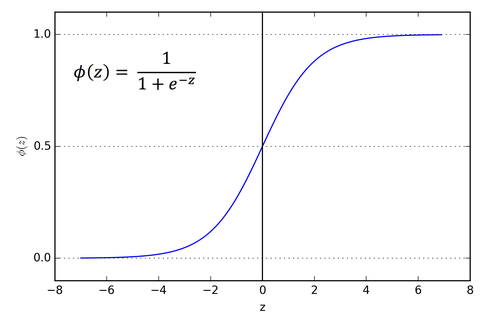

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

data = {
    "hours": [1, 2, 2, 3, 4, 5, 6, 7, 8, 9],
    "attendance": [40, 45, 50, 55, 60, 70, 75, 80, 90, 95],
    "passed": [0, 0, 0, 0, 0, 1, 1, 1, 1, 1]
}

df = pd.DataFrame(data)

# Features
X = df[["hours", "attendance"]]
# Target
y = df["passed"]


# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)
# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# KNN Model
knn = KNeighborsClassifier(n_neighbors=3)

# Train
knn.fit(X_train_scaled, y_train)

# Prediction
y_pred = knn.predict(X_test_scaled)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Predictions:", y_pred)
print("Accuracy:", accuracy)


# ❌ Prediction slow ho sakti hai
# Har new point ke liye distances calculate karni padti hain.
# ❌ Scaling important hai
# Different scales distance ko distort kar sakte hain.
# ❌ Large dataset par expensive
# Agar millions of rows hon to nearest neighbors search costly ho sakti hai.
# ❌ K choose karna important hai
# Bohat small K → overfitting.
# Bohat large K → underfitting.

Predictions: [1 0 1]
Accuracy: 1.0


# SVM

SVM = Support Vector Machine
SVM ek supervised machine learning algorithm hai jo mainly:
Classification, Regression
ke liye use hota hai.
Classification mein SVM ka main goal hota hai:
Classes ko separate karne wali best boundary/hyperplane find karna.

Soft Margin SVM
Real-world data usually perfect nahi hota.
Example:

🔵 🔵 🔵
🔵 🔵    🔴
🔵    🔴 🔴
Classes overlap kar sakti hain.


C parameter kya karta hai?
C SVM ka bohat important hyperparameter hai.
C = 100

High C
 ↓
Mistakes ki high penalty
 ↓
Complex boundary possible
 ↓
Overfitting risk

C = 0.1
Low C
 ↓
More tolerance
 ↓
Wider margin
 ↓
Simpler model

C high → errors ki penalty high
C low → errors tolerate
C batata hai ke SVM galat prediction ko kitna tolerate kare.
C bada → teacher bohat strict 😠
Galat point ko line ke wrong side nahi jaane dega. SVM training data ko zyada accurately fit karega.
C chhota → teacher relaxed 🙂
Kuch galtiyan allow karega, lekin boundary zyada simple/general rakhega.


SVM ka kernel
Ye SVM ka doosra bohat important concept hai.
Agar data straight line se separate nahi ho sakta:
🔵 🔴 🔵
🔴 🔵 🔴
🔵 🔴 🔵
to normal linear boundary kaam nahi karegi.
SVM kernel trick use kar sakta hai.
Common kernels:
linear
poly
rbf
sigmoid

gamma kya hai?
RBF SVM mein important parameter:
Gamma decide karta hai ke ek training point ka influence kitni door tak rahega.

High gamma
 ↓
Point ka influence small area
 ↓
Very flexible boundary
 ↓
Overfitting risk

Low gamma
 ↓
Point ka influence large area
 ↓
Smoother boundary
 ↓
Underfitting risk

Gamma high → local/complex boundary
Gamma low → smooth/simple boundary
Agar model overfit kar raha hai → Gamma kam karo.
Agar model underfit kar raha hai → Gamma barha sakte ho.

SVM mein scaling important hai
SVM ke liye feature scaling generally bohat important hai, especially distance/margin/kernel based setups mein.

In [54]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

data = {
    "hours": [1, 2, 2, 3, 4, 5, 6, 7, 8, 9],
    "attendance": [40, 45, 50, 55, 60,
                   70, 75, 80, 90, 95],

    "passed": [0, 0, 0, 0, 0,
               1, 1, 1, 1, 1]
}

df = pd.DataFrame(data)

X = df[["hours", "attendance"]]
y = df["passed"]


X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


model = SVC(kernel="rbf",C=1.0,gamma="scale")

model.fit(X_train_scaled,y_train)
y_pred = model.predict(X_test_scaled)

# ==========================================
# 8. Evaluation
# ==========================================
accuracy = accuracy_score(y_test,y_pred)
print("\nAccuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test,y_pred))


Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



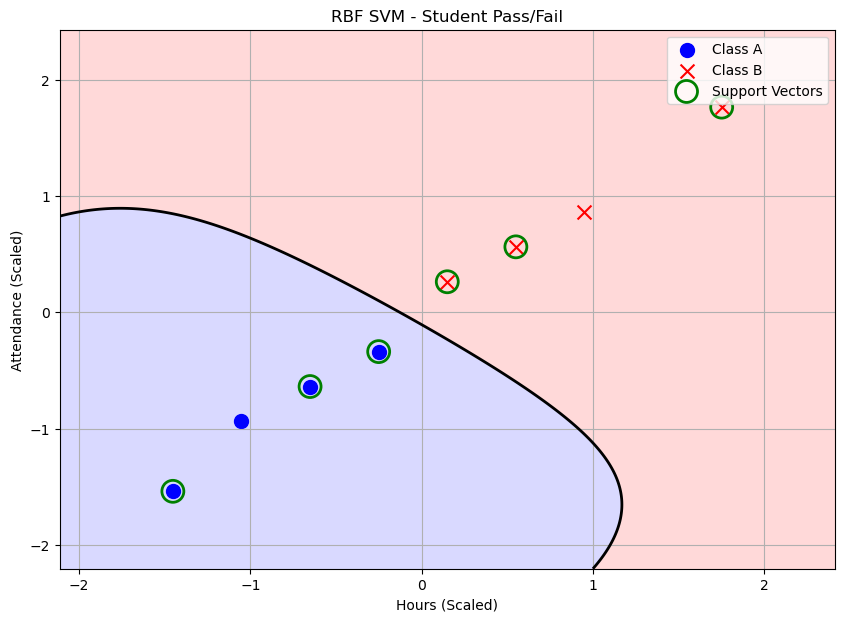

In [59]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 7))
plt.scatter(
    X_train_scaled[y_train.values == 0][:, 0],
    X_train_scaled[y_train.values == 0][:, 1],
    color="blue",
    marker="o",
    s=100,
    label="Class A"
)

plt.scatter(
    X_train_scaled[y_train.values == 1][:, 0],
    X_train_scaled[y_train.values == 1][:, 1],

    color="red",
    marker="x",
    s=100,

    label="Class B"
)

ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(
    xlim[0] - 0.5,
    xlim[1] + 0.5,
    500
)
yy = np.linspace(
    ylim[0] - 0.5,
    ylim[1] + 0.5,
    500
)

YY, XX = np.meshgrid(
    yy,
    xx
)

xy = np.vstack(
    [
        XX.ravel(),
        YY.ravel()
    ]
).T

Z = model.decision_function(
    xy
).reshape(
    XX.shape
)

plt.contourf(
    XX,
    YY,
    Z,
    levels=[Z.min(), 0, Z.max()],
    alpha=0.15,
    colors=["blue", "red"]
)

plt.contour(
    XX,
    YY,
    Z,
    levels=[0],
    colors="black",
    linewidths=2
)

plt.scatter(
    model.support_vectors_[:, 0],
    model.support_vectors_[:, 1],
    s=250,
    facecolors="none",
    edgecolors="green",
    linewidths=2,
    label="Support Vectors"
)

plt.xlabel("Hours (Scaled)")
plt.ylabel("Attendance (Scaled)")
plt.title("RBF SVM - Student Pass/Fail")
plt.legend()
plt.grid(True)
plt.show()

predictions [1 0]
Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



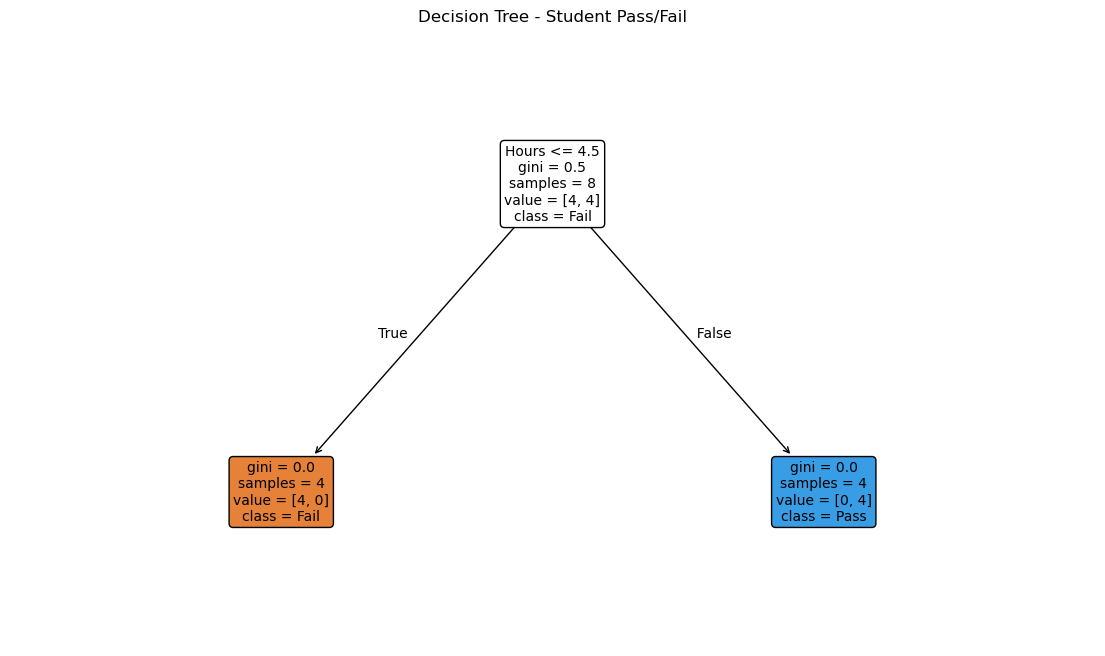

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import plot_tree

data = {
    "hours": [
        1, 2, 2, 3, 4,
        5, 6, 7, 8, 9
    ],

    "attendance": [
        40, 45, 50, 55, 60,
        70, 75, 80, 90, 95
    ],

    "passed": [
        0, 0, 0, 0, 0,
        1, 1, 1, 1, 1
    ]
}


df = pd.DataFrame(data)

X = df[
    [
        "hours",
        "attendance"
    ]
]
y = df["passed"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = DecisionTreeClassifier(criterion="gini",max_depth=3,random_state=42)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print("predictions", y_pred)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:",accuracy)
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)


plt.figure(
    figsize=(14, 8)
)
plot_tree(
    model,

    feature_names=[
        "Hours",
        "Attendance"
    ],

    class_names=[
        "Fail",
        "Pass"
    ],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree - Student Pass/Fail")
plt.show()

Random Forest ka complete process

              Original Dataset
                     |
          ┌──────────┼──────────┐
          ↓          ↓          ↓
       Sample 1   Sample 2   Sample 3
          |          |          |
          ↓          ↓          ↓
       Tree 1     Tree 2     Tree 3
          |          |          |
          ↓          ↓          ↓
        Pass       Pass       Fail
          \          |          /
           \         |         /
            ↓        ↓        ↓
             Majority Voting
                    |
                    ↓
                  PASS


Predictions:
[1 1 1 1 0 0]

Actual Values:
[1 1 1 1 0 0]

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00         2
        Pass       1.00      1.00      1.00         4

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6


Confusion Matrix:
[[2 0]
 [0 4]]


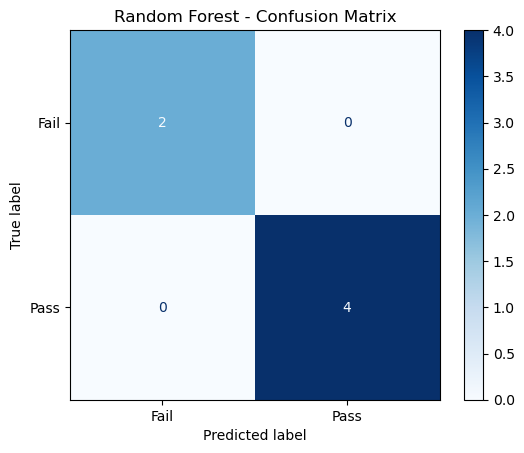


Feature Importance:
          Feature  Importance
1      attendance    0.343576
3  previous_marks    0.275510
2     assignments    0.204627
0           hours    0.176286


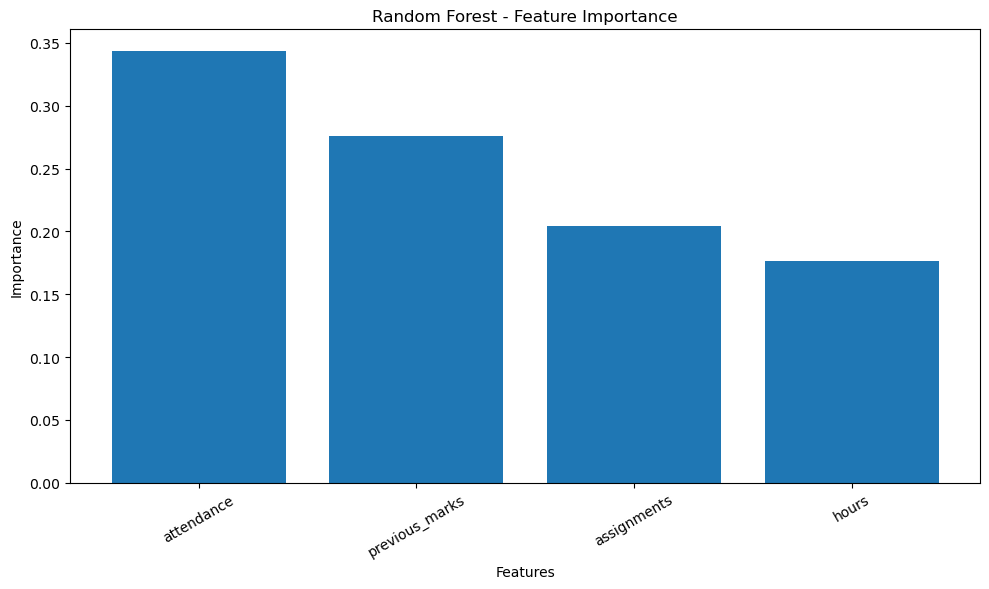


New Student Prediction:
PASS


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

data = {

    "hours": [
        1, 2, 2, 3, 3,
        4, 4, 5, 5, 5,
        6, 6, 6, 7, 7,
        7, 8, 8, 8, 9,
        9, 4, 5, 6, 7,
        2, 3, 8, 9
    ],

    "attendance": [
        40, 45, 50, 55, 58,
        60, 65, 68, 70, 72,
        75, 78, 80, 82, 84,
        85, 88, 90, 92, 95,
        96, 70, 76, 81, 86,
        48, 55, 89, 94
    ],

    "assignments": [
        2, 3, 3, 4, 4,
        5, 5, 6, 6, 6,
        7, 7, 7, 8, 8,
        8, 9, 9, 9, 10,
        10, 5, 6, 7, 8,
        3, 4, 9, 10
    ],

    "previous_marks": [
        35, 40, 42, 45, 48,
        50, 52, 55, 58, 60,
        62, 64, 66, 68, 70,
        72, 74, 76, 78, 82,
        85, 55, 60, 65, 70,
        38, 45, 78, 88
    ],

    "passed": [
        0, 0, 0, 0, 0,
        0, 0, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        0, 0, 1, 1
    ]
}

df = pd.DataFrame(data)

X = df[
    [
        "hours",
        "attendance",
        "assignments",
        "previous_marks"
    ]
]
y = df["passed"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


model = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_depth=5,
    random_state=42
)

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print("\nPredictions:")
print(y_pred)

print("\nActual Values:")
print(y_test.values)

accuracy = accuracy_score(y_test,y_pred)
print("\nAccuracy:", accuracy)


print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Fail",
            "Pass"
        ]
    )
)


# ==========================================
# 10. CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Fail",
        "Pass"
    ]
)

disp.plot(cmap="Blues")
plt.title("Random Forest - Confusion Matrix")
plt.show()

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
print(importance)


plt.figure(figsize=(10, 6))
plt.bar(importance["Feature"],importance["Importance"])
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Random Forest - Feature Importance")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


new_student = pd.DataFrame({
    "hours": [6],
    "attendance": [85],
    "assignments": [8],
    "previous_marks": [70]
})

prediction = model.predict(new_student)
print("\nNew Student Prediction:")

if prediction[0] == 1:

    print("PASS")
else:
    print("FAIL")

XGBoost:
XGBoost mein trees one-by-one bante hain, aur har naya tree pichle trees ki mistakes ko improve karne ki koshish karta hai.

XGBoost = Extreme Gradient Boosting
Ye ek powerful gradient boosting algorithm hai jo mainly:
Classification
Regression
Ranking

Tree 1
  ↓
Mistakes identify karo
  ↓
Tree 2
  ↓
Remaining mistakes improve karo
  ↓
Tree 3
  ↓
Remaining mistakes improve karo
  ↓
...
  ↓
Final Model


learning_rate:
ya jitna kam hoga utni training achi hogi lkain time b zeyda lagay ga
Iska simple concept:
Har new tree model ke final result mein kitna contribute kare?
learning_rate = 0.1
to har tree ka contribution relatively small hoga.
learning_rate = 0.5 
to har tree ka contribution comparatively large ho sakta hai.


subsample=0.8
ka matlab roughly:
Har boosting round mein training data ka 80% sample use karo.
Ye randomness introduce kar sakta hai aur overfitting control karne mein help kar sakta hai.

colsample_bytree=0.8
to each tree ke liye features ka subset use kiya ja sakta hai.
Ye Random Forest ke feature randomness concept se somewhat related hai, lekin XGBoost ka overall learning mechanism boosting hai.

XGBoost kab use hota hai?
XGBoost especially structured/tabular data ke liye bohat popular hai.
Banking, E-commers, Real Estate, education, ...



In [6]:
# pip install xgboost

In [7]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("prediction", y_pred)
print("Accuracy:", accuracy)

prediction [1 1 1 1 0 0]
Accuracy: 1.0


# CatBoost:
CatBoost is a state-of-the-art open-source gradient boosting on decision trees library.

 Do we need to encode categorical features before training the model? No, CatBoost does not require it.

CatBoost = Categorical Boosting
Ye specially categorical data ko efficiently handle karne ke liye design kiya gaya hai.
Tree 1
  ↓
Tree 2 → previous model improve
  ↓
Tree 3 → previous model improve
  ↓
Tree 4 → previous model improve
  ↓
...
  ↓
Final Model

loss_function="Logloss",
is matlab previas tree se jo err aya hain os ko yad rakho

verbose=False/Trur
agar true hoga tu tree ki traing nazar aye ki or false pr ni nazar aye gi

. It is developed by Yandex researchers and engineers, and is used for search, recommendation systems, personal assistant, self-driving cars,
weather prediction and many other tasks at Yandex and in other companies.
. It is in Python and it is designed to be integrated in data science pipelines.
. It provides state-of-the-art results and it is powerful in handling categorical features.
. Do we need to encode categorical features before training the model? No, CatBoost does not require it.
. It is efficient. It provides a fast and scalable multi-threaded implementation of the algorithm.
. It provides powerful visualization tools to understand the model.




In [9]:
# !pip install catboost


Missing Values after handling:
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alone          0
dtype: int64

Predictions:
[0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0
 0 0 1 0 1 0 1 1 0 0 0 1 1 1 0 1 0 1 0 0 1 0 0 1 1 0 0 1 0 1 0 0 0 1 0 1 1
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 1 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 0 0 0 1 0 0 0 0 0
 1 1 0 1 1 1 0 1 0 0 0 1 1 1 1 1 1 0 0 0 1 0 0 0 0 0 1 0 0 1 0]

Actual Values:
[0 0 1 0 1 1 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 1 0 1 0 1 1 0 0 1 1 0 1 1 1
 0 0 1 0 0 0 1 1 0 0 0 1 1 1 0 0 1 1 0 0 1 1 1 0 1 0 0 1 0 1 0 0 0 1 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 1 0 0 1 1 0 0 1 0 1 1 1 0 1 0 0 0 0 0
 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 1 1 0 0 1 0 0 1 0 0
 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1 1 1 0 0 0

<Figure size 700x600 with 0 Axes>

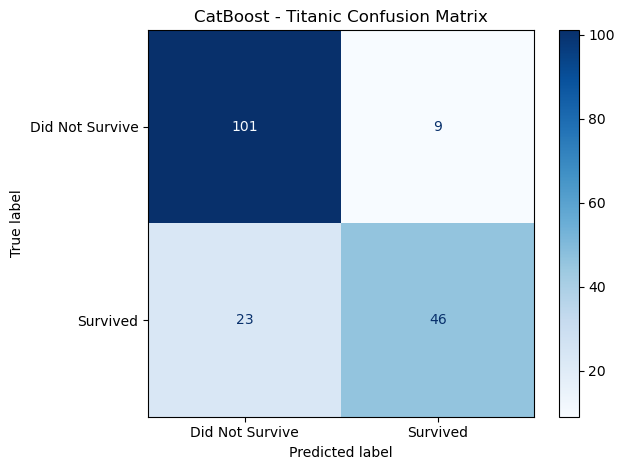


Feature Importance:
        Feature  Importance
5          fare   14.047370
7         class   12.540111
8           who   12.395625
2           age   11.529716
9    adult_male   10.155851
1           sex   10.001497
10         deck    8.627342
0        pclass    6.188827
6      embarked    5.259385
3         sibsp    3.802401
11  embark_town    3.187456
4         parch    1.518638
12        alone    0.745782


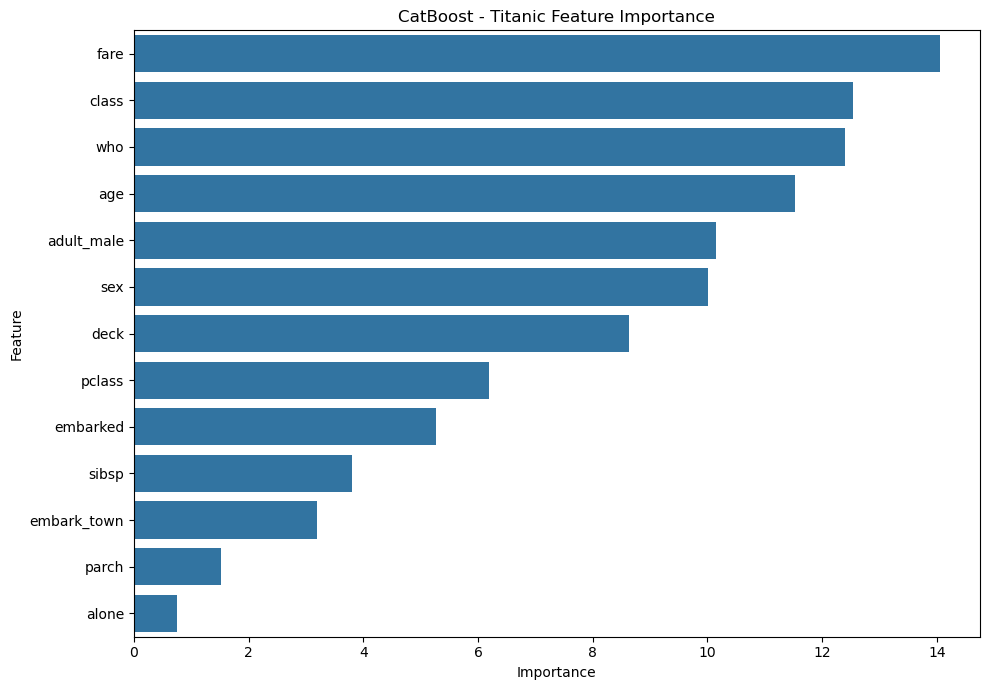

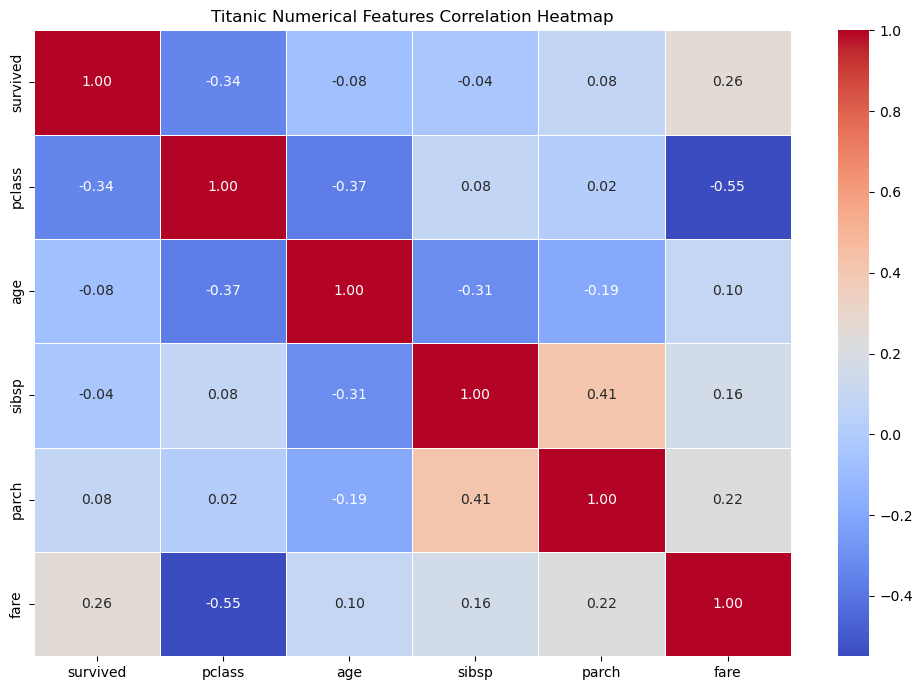

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from catboost import CatBoostClassifier

df = sns.load_dataset("titanic")

df = df.drop(columns=["alive"])

object_columns = df.select_dtypes(
    include=["object"]
).columns


for column in object_columns:
    df[column] = df[column].astype("category")
# Target

y = df["survived"]
X = df.drop(columns=["survived"])


numeric_columns = X.select_dtypes(
    include=["number"]
).columns

for column in numeric_columns:
    X[column] = X[column].fillna(
        X[column].median()
    )


# Categorical columns
categorical_columns = X.select_dtypes(
    include=["category"]
).columns


for column in categorical_columns:
    # Category column mein "Missing" add karna zaroori hai
    if "Missing" not in X[column].cat.categories:
        X[column] = X[column].cat.add_categories(
            ["Missing"]
        )
    X[column] = X[column].fillna(
        "Missing"
    )
print("\nMissing Values after handling:")
print(X.isnull().sum())



X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


model = CatBoostClassifier(iterations=300,learning_rate=0.05,depth=6,loss_function="Logloss",eval_metric="Accuracy",random_seed=42,verbose=False)

cat_features = X.select_dtypes(
    include=["category"]
).columns.tolist()

model.fit(X_train,y_train,cat_features=cat_features)


y_pred = model.predict(X_test)
y_pred = y_pred.astype(int).flatten()

print("\nPredictions:")
print(y_pred)
print("\nActual Values:")
print(y_test.values)


accuracy = accuracy_score(y_test,y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100)


print("\nClassification Report:")
print(classification_report(y_test,y_pred,target_names=["Did Not Survive","Survived"]))

cm = confusion_matrix(y_test,y_pred)
print("\nConfusion Matrix:")
print(cm)



plt.figure(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Did Not Survive",
        "Survived"
    ]
)


disp.plot(
    cmap="Blues",
    values_format="d"
)


plt.title("CatBoost - Titanic Confusion Matrix")
plt.tight_layout()
plt.show()
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})


importance = importance.sort_values(
    by="Importance",
    ascending=False
)
print("\nFeature Importance:")
print(importance)


plt.figure(figsize=(10, 7))
sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)


plt.title("CatBoost - Titanic Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()



# Heatmap ke liye numerical columns use karenge.
# Categorical columns ko direct correlation mein use
# karna meaningful nahi hota.

numeric_df = df.select_dtypes(include=["number"])
correlation = numeric_df.corr()
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Titanic Numerical Features Correlation Heatmap")
plt.tight_layout()
plt.show()

# Naive Bayes
Naive Bayes ek probabilistic classification algorithm hai jo Bayes' Theorem par based hota hai.

Simple language mein:
Naive Bayes different features ko dekh kar calculate karta hai ke kisi observation ke different classes mein belong karne ki probability kitni hai.


Naive Bayes ko kab use karna chahiye?
⭐ Strong choice:
Text classification
Spam detection
Sentiment analysis
Document classification
News classification
...

Naive Bayes:
Probability calculate karta hai.
Feature 1 ──┐
Feature 2 ──┤
Feature 3 ──┤
Feature 4 ──┘
      ↓
Probability
      ↓
Highest probability
      ↓
Prediction

Naive Bayes = "Features ko dekh kar har class ke chances/probability nikalo, jis class ke chances sabse zyada hon usko answer bana do."


Ye nahi kehta:
feature1 aur feature2 duniya mein bilkul unrelated hain.
Ye kehta hai:
Prediction calculate karte waqt main in features ki dependencies ko ignore/approximate karunga.

Type of Naive Bayes:
Gaussian Naive Bayes
Used for continuous numerical data.
Assumes features follow a Gaussian (normal) distribution.
Example: height, weight, temperature.
Multinomial Naive Bayes
Commonly used for text classification.
Works well with word counts or term frequencies.
Example: spam detection, document classification.
Bernoulli Naive Bayes
Used when features are binary (0/1 or yes/no).
Example: whether a particular word appears in an email.
Categorical Naive Bayes
Used for categorical features.
Example: color = red/blue/green, education = school/college/university.
Complement Naive Bayes
A variation of Multinomial Naive Bayes, particularly useful for imbalanced datasets.
Often used in text classification.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


data = {

    "hours": [
        1, 2, 2, 3, 4,
        5, 6, 7, 8, 9
    ],

    "attendance": [
        40, 45, 50, 55, 60,
        70, 75, 80, 90, 95
    ],

    "passed": [
        0, 0, 0, 0, 0,
        1, 1, 1, 1, 1
    ]
}


df = pd.DataFrame(data)
X = df[["hours","attendance"]]
y = df["passed"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

model = GaussianNB()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

print(classification_report(y_test,y_pred))

cm = confusion_matrix(y_test,y_pred)
print("Confusion Matrix:")
print(cm)

probabilities = model.predict_proba(X_test)
print(probabilities)

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2

Confusion Matrix:
[[1 0]
 [0 1]]
[[9.99924311e-01 7.56888907e-05]
 [2.09040832e-15 1.00000000e+00]]


In [6]:
from sklearn.naive_bayes import (
    GaussianNB,
    MultinomialNB,
    BernoulliNB,
    CategoricalNB,
    ComplementNB
)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()
cnb = CategoricalNB()
comp_nb = ComplementNB()


#gnb
gnb.fit(X_train,y_train)
y_pred_gnb = gnb.predict(X_test)
accuracy_gnb = accuracy_score(y_test,y_pred_gnb)
print("Accuracy gnb:",accuracy_gnb)
print(classification_report(y_test,y_pred_gnb))
cm_gnb = confusion_matrix(y_test,y_pred_gnb)
print("Confusion Matrix gnb:")
print(cm_gnb)
probabilities_gnb = gnb.predict_proba(X_test)
print(probabilities_gnb)


#mnb
mnb.fit(X_train,y_train)
y_pred_mnb = mnb.predict(X_test)
accuracy_mnb = accuracy_score(y_test,y_pred_mnb)
print("Accuracy mnb:",accuracy_mnb)
print(classification_report(y_test,y_pred_mnb))
cm_mnb = confusion_matrix(y_test,y_pred_mnb)
print("Confusion Matrix mnb:")
print(cm_mnb)
probabilities_mnb = gnb.predict_proba(X_test)
print(probabilities_mnb)


#bnb
bnb.fit(X_train, y_train)
y_pred_bnb = bnb.predict(X_test)
accuracy_bnb = accuracy_score(y_test, y_pred_bnb)
print("Accuracy bnb:", accuracy_bnb)
print(classification_report(y_test, y_pred_bnb))
cm_bnb = confusion_matrix(y_test, y_pred_bnb)
print("Confusion Matrix bnb:")
print(cm_bnb)
probabilities_bnb = bnb.predict_proba(X_test)
print(probabilities_bnb)

# comp_nb
comp_nb.fit(X_train, y_train)
y_pred_comp_nb = comp_nb.predict(X_test)
accuracy_comp_nb = accuracy_score(y_test, y_pred_comp_nb)
print("Accuracy comp_nb:", accuracy_comp_nb)
print(classification_report(y_test, y_pred_comp_nb))
cm_comp_nb = confusion_matrix(y_test, y_pred_comp_nb)
print("Confusion Matrix comp_nb:")
print(cm_comp_nb)
probabilities_comp_nb = comp_nb.predict_proba(X_test)
print(probabilities_comp_nb)

#cnb
X["study_level"] = [0, 0, 0, 1, 1,1, 2, 2, 2, 2]
X["attendance_level"]= [0, 0, 1, 1, 1, 2, 2, 2, 3, 3]
X = X[["study_level", "attendance_level"]]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.5,random_state=42,stratify=y)
cnb.fit(X_train, y_train)
y_pred_cnb = cnb.predict(X_test)
accuracy_cnb = accuracy_score(y_test, y_pred_cnb)
print("Accuracy cnb:", accuracy_cnb)
print(classification_report(y_test, y_pred_cnb))
cm_cnb = confusion_matrix(y_test, y_pred_cnb)
print("Confusion Matrix cnb:")
print(cm_cnb)
probabilities_cnb = cnb.predict_proba(X_test)
print(probabilities_cnb)

Accuracy gnb: 0.8
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       1.00      0.50      0.67         2

    accuracy                           0.80         5
   macro avg       0.88      0.75      0.76         5
weighted avg       0.85      0.80      0.78         5

Confusion Matrix gnb:
[[3 0]
 [1 1]]
[[1.00000000e+00 0.00000000e+00]
 [1.00000000e+00 0.00000000e+00]
 [1.00000000e+00 0.00000000e+00]
 [1.00000000e+00 0.00000000e+00]
 [1.53762899e-23 1.00000000e+00]]
Accuracy mnb: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5

Confusion Matrix mnb:
[[3 0]
 [0 2]]
[[1.00000000e+00 0.00000000e+00]
 [1.00000000e+00 0.00000000e+00]
 [1.

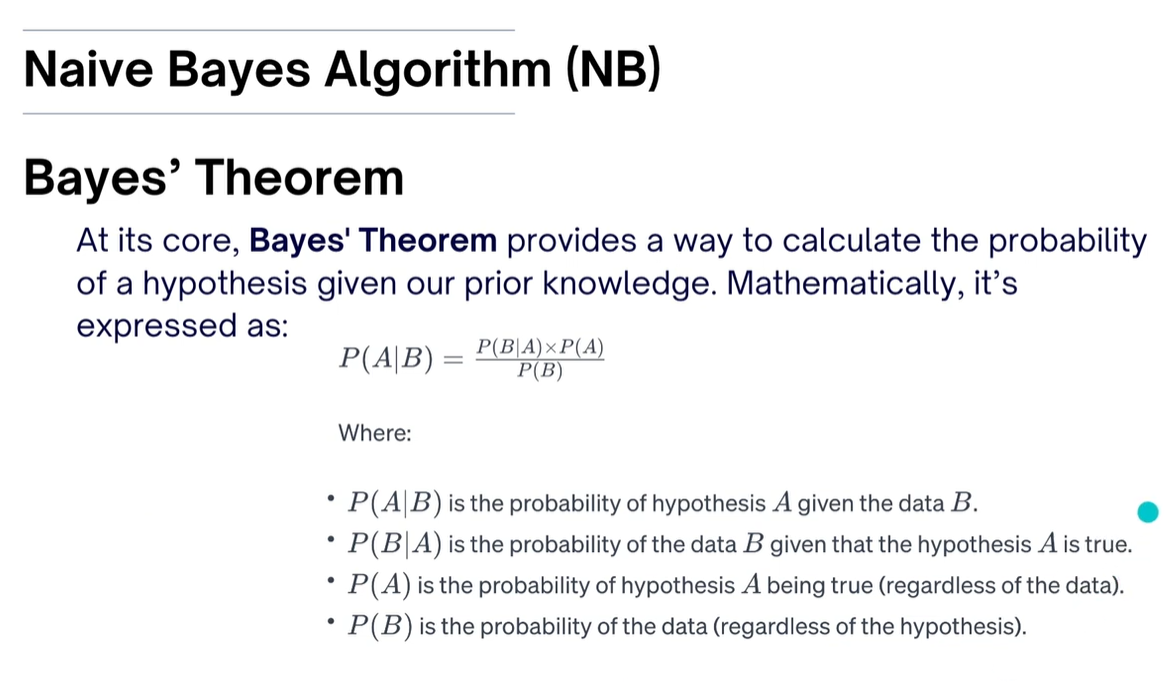

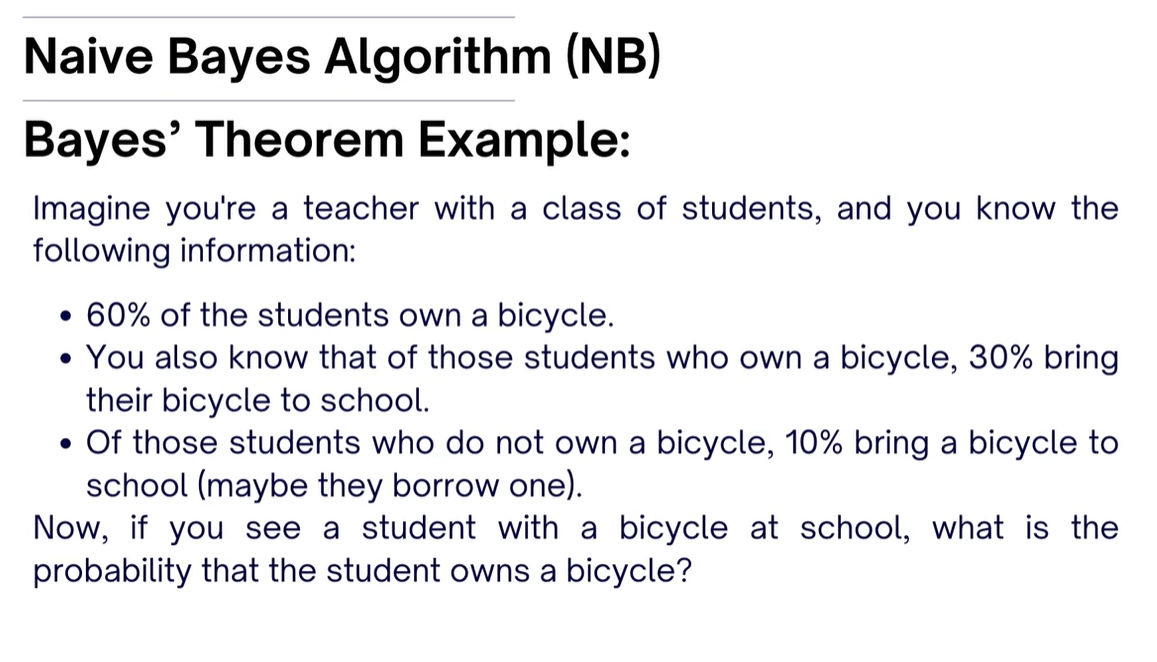

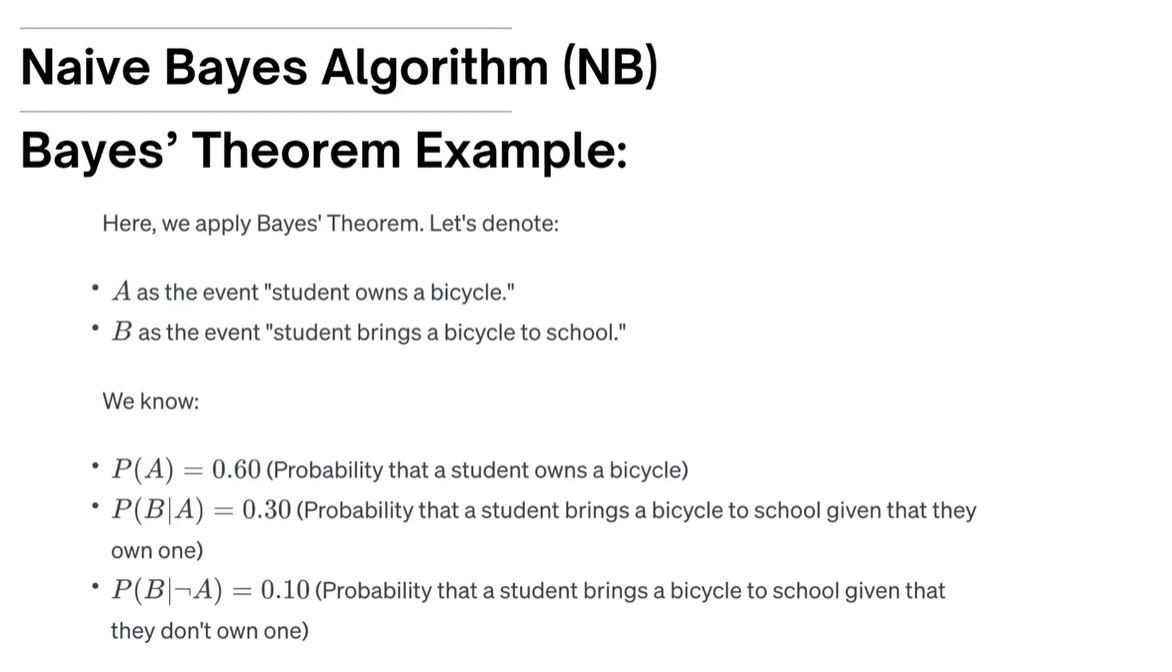

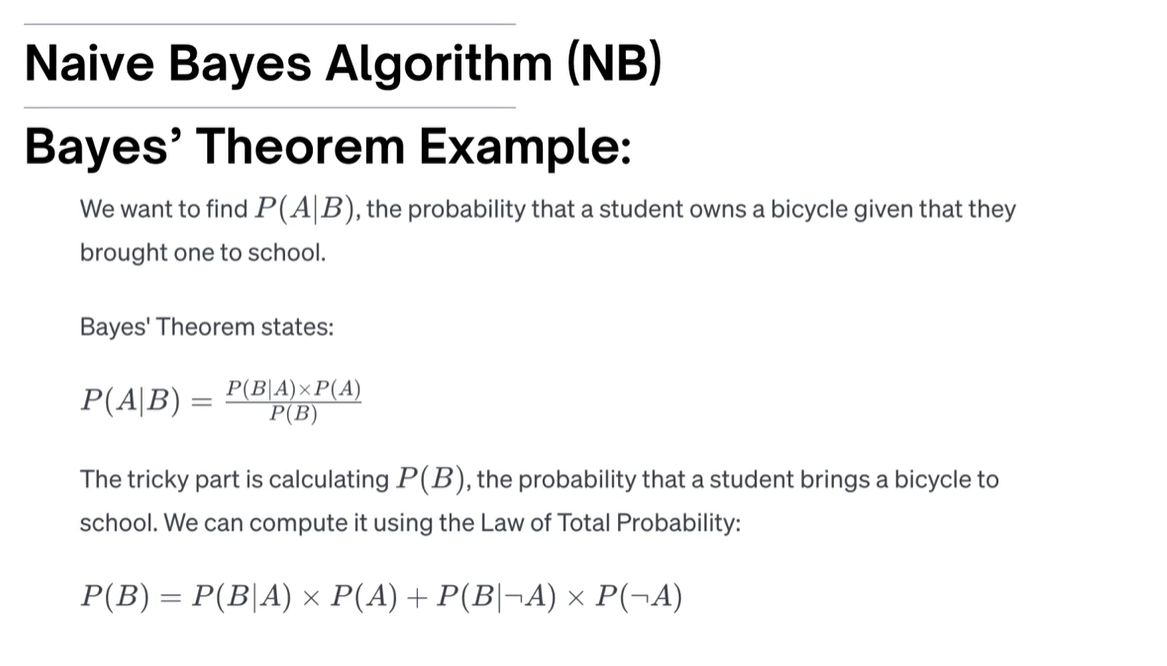

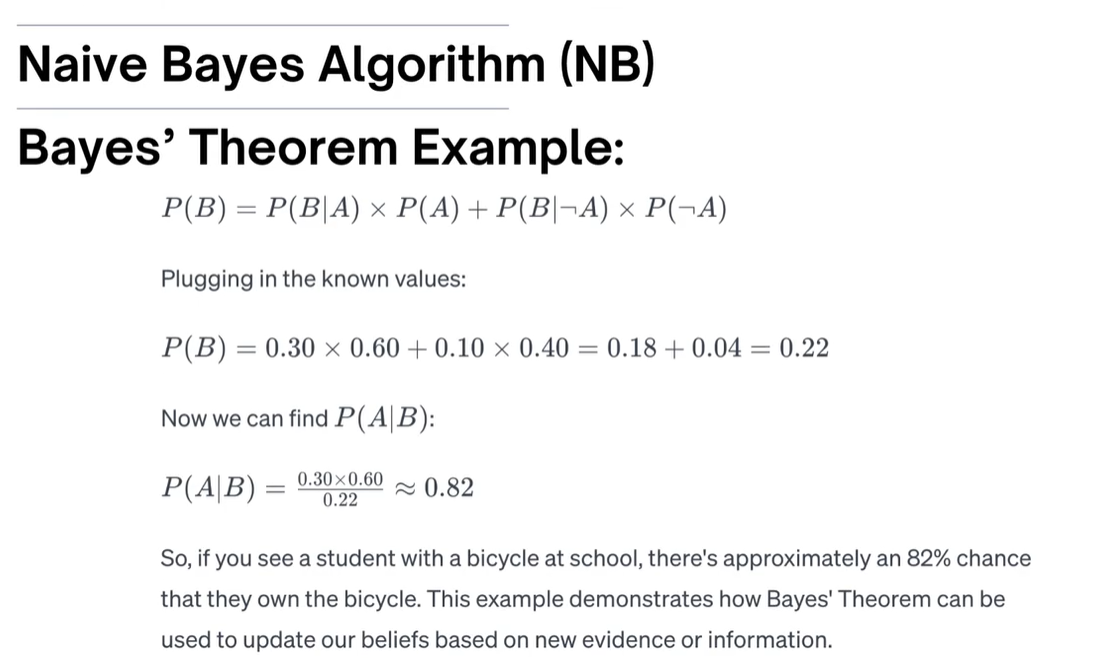

# unsupervised

# k-mean
n_clusters = kitne group main divide krna hain default value n_clusters=8
init =  batata hai ke starting centroids (centers) kahan se choose karne hain.
init="k-means++" ya default b hota hain 
Starting centers ko smart tareeqe se choose karta hai. Usually best/default choice.
init="random"
Starting centers ko randomly choose karta hai.

n_init: default value n_init="auto"
Socho tumhare paas 3 groups banane hain. K-Means ek baar randomly/smartly centers choose karta hai aur result nikalta hai. Lekin ho sakta hai pehli baar best result na aaye.

init = starting centers kaise choose karne hain?
n_init = starting centers kitni baar try karne hain?

max_iter:
Ek run ke andar K-Means maximum kitni baar apne groups aur centers ko update karega.
K-Means maximum 100 iterations tak try karega.
Agar groups 20 iterations mein hi stable ho gaye, to 100 tak wait nahi karega—wahin stop ho jayega.

n_init=10 → K-Means 10 different starting points se try karega.
max_iter=100 → har ek try ke andar maximum 100 baar update karega.

tol ka matlab hai tolerance. default value tol=0.0001
"K-Means ko kitni chhoti change par samajh lena chahiye ke ab result stable hai aur stop kar do." mean k-mean change karne hai lkain agar wo cahnge bhot chota hain tu os change result pr koi khas asar ni hota tu hum phaly he stop kar de gay 

algorithm:
algorithm batata hai ke K-Means calculation kis method se karega.

lloyd → standard K-Means method. Ye normal/default choice hai.
Har bachay ka distance center se check karo → groups update karo → repeat

elkan → kuch datasets mein distance calculations ko efficiently reduce kar sakta hai, lekin generally dense data ke liye useful hai.
Kuch distances ko smartly skip karke calculation kam karne ki koshish karta hai. 
asa tb karte hain jb man lo bhot se bhot ak sath ho or takreeban point ka distance centriod same ho tu agar hum kuch point skip kar de tu os se koi farq ni aye ga result pr or calculation kam hone ki waja se model b fast train hoga 

kmeans = KMeans(
    n_clusters=8,
    init="k-means++",
    n_init="auto",
    max_iter=300,
    tol=0.0001,
    random_state=None,
    algorithm="lloyd"
)

[[-2.63323268  9.04356978]
 [-6.88387179 -6.98398415]
 [ 4.74710337  2.01059427]]


c:\Users\Tech Mart\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


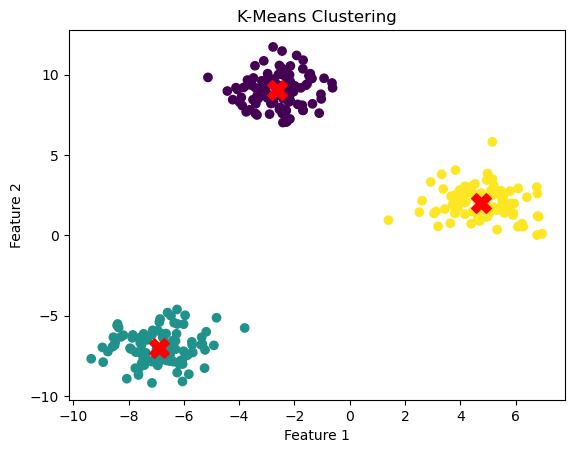

In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Data
X, y = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.0,
    random_state=42
)

# K-Means
kmeans = KMeans(n_clusters=3,random_state=42)

# Train
kmeans.fit(X)

# Clusters
labels = kmeans.labels_
# print(labels)
# labels matlab group mean konsa point kis group ka hain 

# Centroids
centroids = kmeans.cluster_centers_
print(centroids)

# Plot
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis")

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c="red",
    marker="X",
    s=200
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering")
plt.show()


# Hierarchical Clustering
Similar data points ko groups (clusters) mein arrange karna.
Isko Hierarchical isliye kehte hain kyunki ye clusters ko tree/hierarchy ki form mein arrange karta hai.
mean is main hum jo point kareeb kareeb hote hain on ka group bana detay hain yaha hum cluster ki value ni batate lakin ya slow hota hain khas kar bary data ky leya Q ky ya ak akpoint single cluster banata hai  phr check karta hain konse point apas main kareeb hain phr on ko mila kar ak or cluster bana leta hain phr os check karta hain wo group kis point ya group ky kareeb hain os ka dosre point ya group ky sath group bana leta hain 

like:
Student A → 90
Student B → 85
Student C → 88
Student D → 40
Student E → 35
Student F → 42

Shuru mein har point apna separate cluster hai:
[A] [B] [C] [D] [E] [F]

phr Kaun sabse zyada close hai?
A aur B close hain
C aur D close hain
E aur F close hain

[AB] [CD] [EF]

[AB] aur [CD] close hain
to
[ABCD] [EF]

[ABCD] aur [EF] ab yahi close hain agar ni b hain tu yahi last hai  do ab in dono ka group bane ga

[ABCDEF] like this

Hierarchical Clustering ke 2 types
Hierarchical clustering ke 2 main approaches 

Agglomerative:
Bottom → Up

Individual points
       ↓
Small clusters
       ↓
Bigger clusters
       ↓
One big cluster

dendrogram:
Agglomerative Clustering ka dendrogram
Distance
  ↑
  |
8 |              ┌───────────────┐
  |              │               │
6 |       ┌──────┤               │
  |       │      │               │
4 |   ┌───┤      │      ┌────────┤
  |   │   │      │      │        │
2 |   │   │      │      │        │
  |   │   │      │      │        │
  +---A---B------C------D--------E


Divisive:
Top → Down
One big cluster
       ↓
Split
       ↓
Smaller clusters
       ↓
Individual points

dendrogram:
Divisive Clustering ka dendrogram

             {A,B,C,D,E}
                    │
              Distance 6
              ┌─────┴─────┐
              ↓           ↓
           {A,B,C}      {D,E}
              │           │
        Distance 4    Distance 4
          ┌───┴───┐     ┌─┴─┐
          ↓       ↓     ↓   ↓
        {A,B}     C     D   E
          │
     Distance 2
        ┌─┴─┐
        A   B

Divisive Clustering algorithm available nahi hai. is leya hum is ky leya kmean ya use kar sakte hain Divisive ak technique hain os ky bad hum koi b algorithm ka use karty howay is technique ko bana sakte hain


Linkage:
Do clusters ke beech distance kaise calculate karni hai?
linkage="single"
single bolta hain closest point ka group banado 

linkage="complete"
complete bolta hain dorwala  point ka group banado phlay 

linkage="average"
Pehle do clusters ke har point ke darmiyan distance lo.
Phir un sab distances ka average nikalo.
Jis 2 clusters ka average sabse chhota ho, unko merge/group kar do.

linkage="ward"
Har possible pair of clusters ko merge karne ka socho.
Har merge ke baad SSE(Sum of Squared Errors.) (within-cluster variation) calculate karo.
Jis merge se SSE mein sabse chhota increase aaye → woh groups merge karo.

linkage="Centroid"
Cluster A = {2, 4} → centroid = 3
Cluster B = {8, 10} → centroid = 9
Cluster C = {3, 5} → centroid = 4

ab distance calculate hoga jis ka kam distance hoga wo group ho jaye gay 
distance = ∣B − A∣ => ∣9 − 3∣ = 6
distance = ∣B − C∣ => ∣9 − 4∣ = 5
distance = ∣C − A∣ => ∣4 − 3∣ = 1

ab dekho C or A distance kam hain tu is group bana do 

Hierarchical hyperparameters 

n_clusters:
Jab Hierarchical Clustering khud hierarchy bana raha hai, to hum n_clusters khud kyun dete hain?
Hierarchical Clustering pehle poori hierarchy banata hai:
[A] [B] [C] [D] [E]
 ↓   ↓   ↓   ↓   ↓
[AB] [C] [DE]
     ↓
[ABC] [DE]
     ↓
[ABCDE]

Ab machine ne hierarchy bana di. Lekin humein final mein decide karna hai:
Mujhe is hierarchy mein se kitne groups chahiye?

n_clusters=2
Cluster 1 → A B C
Cluster 2 → D E

n_clusters=3
Cluster 1 → A B
Cluster 2 → C
Cluster 3 → D E
n_clusters = final mein kitne groups chahiye.


metric:
ya distance kaise calculate karna hain os ka perameter hain 
value = euclidean,manhattan,cosine,minkowski,chebyshev

Lekin ward linkage ke saath sirf Euclidean metric allowed hota hai. ⚠️

metric:
👉 Do individual points ke beech distance ka formula.
linkage:
👉 Do clusters ke beech distance kaise define karni hai.


distance_threshold:
Agglomerative algorithm clusters ko merge karta rehta hai:
[A] [B] [C] [D] [E]
 ↓
[AB] [C] [DE]
 ↓
[ABC] [DE]
 ↓
[ABCDE]

Har merge ke waqt ek distance hoti hai.
A + B  → distance = 2
D + E  → distance = 3
AB + C → distance = 5
ABC + DE → distance = 10
Ab hum bolte hain: ====>  distance_threshold=5
5 tak merging hone do, uske baad stop
distance 2 → merge ✅
distance 3 → merge ✅
distance 5 → merge ✅
distance 10 → merge ❌
[ABC]    [DE]
Yani 2 clusters.

Method 1 — n_clusters
Mujhe n groups chahiye

Method 2 — distance_threshold
Merging tab tak karo jab tak distance is limit se zyada na ho
smein number of clusters tum directly specify nahi kar rahe.

n_clusters or distance_threshold ko ek saath specify nahi karte.


compute_full_tree:
compute_full_tree ki do value hain True or false 
↓
compute_full_tree=False
Algorithm unnecessary merging ko avoid karke required number of clusters tak ruk sakta hai.False mean kitne cluster chahiya agar ban jaye tu bs ruk jao 
compute_full_tree=True
Puri tree calculate karo.
Ye useful ho sakta hai jab tum distance_threshold use kar rahe ho ya multiple cluster counts explore karna chahte ho.
compute_full_tree=auto ==> Sklearn khud decide karega ke poora hierarchical tree/dendrogram calculate karna hai ya nahi.

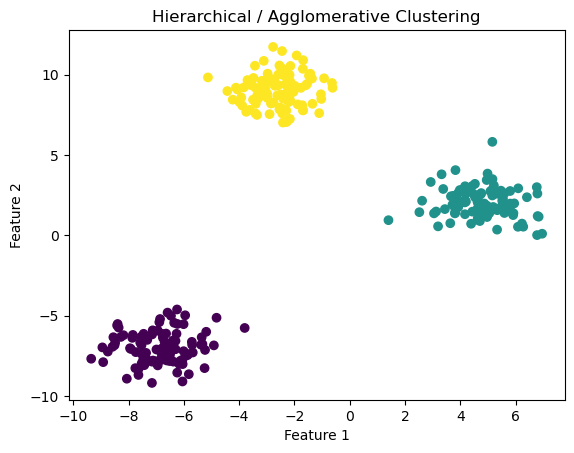

In [25]:
# N cluster
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# 1. Data create karna
X, y = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.0,
    random_state=42
)

# 2. Agglomerative Clustering
model = AgglomerativeClustering(
    n_clusters=3,
    metric="euclidean",
    linkage="ward",
    distance_threshold=None,
    compute_full_tree="auto"
)

# 3. Clustering
labels = model.fit_predict(X)

# 4. Clusters ko plot karna
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    cmap="viridis"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Hierarchical / Agglomerative Clustering")

plt.show()


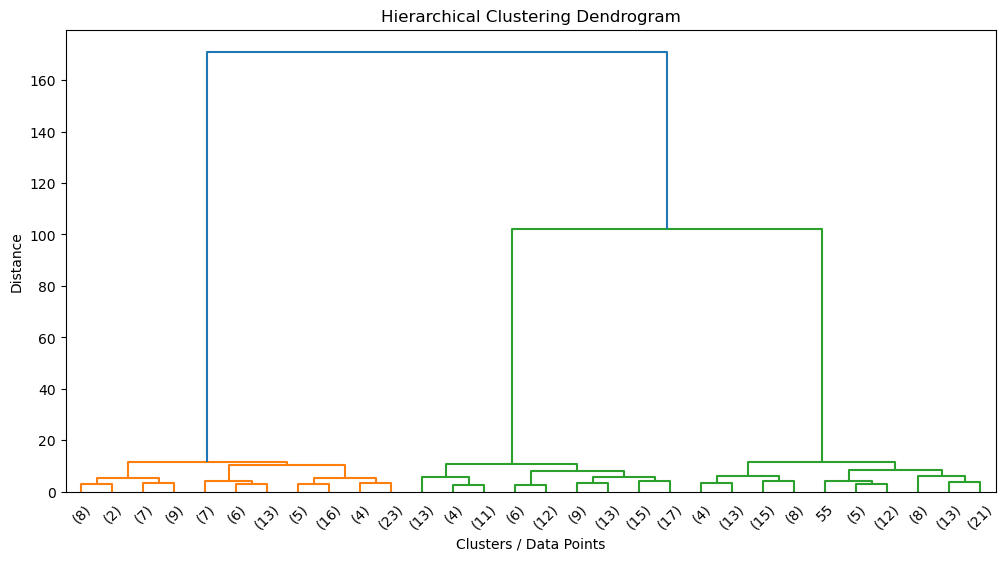

In [27]:
# Dendrogram Graph
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

Z = linkage(
    X,
    method="ward",
    metric="euclidean"
)

plt.figure(figsize=(12, 6))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=30
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Clusters / Data Points")
plt.ylabel("Distance")

plt.show()


Number of clusters: 5


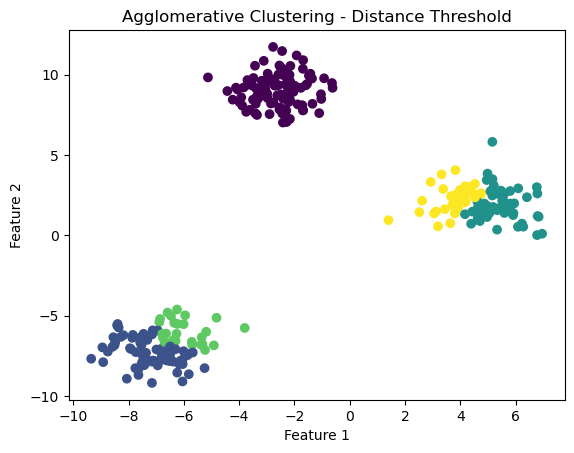

In [31]:
# threshold
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# 1. Data create karna
X, y = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.0,
    random_state=42
)

# 2. Agglomerative Clustering
model = AgglomerativeClustering(
    n_clusters=None,
    metric="euclidean",
    linkage="ward",
    distance_threshold=11
)

# 3. Clustering
labels = model.fit_predict(X)

# 4. Total clusters check karna
print("Number of clusters:", model.n_clusters_)

# 5. Graph
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    cmap="viridis"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Agglomerative Clustering - Distance Threshold")

plt.show()


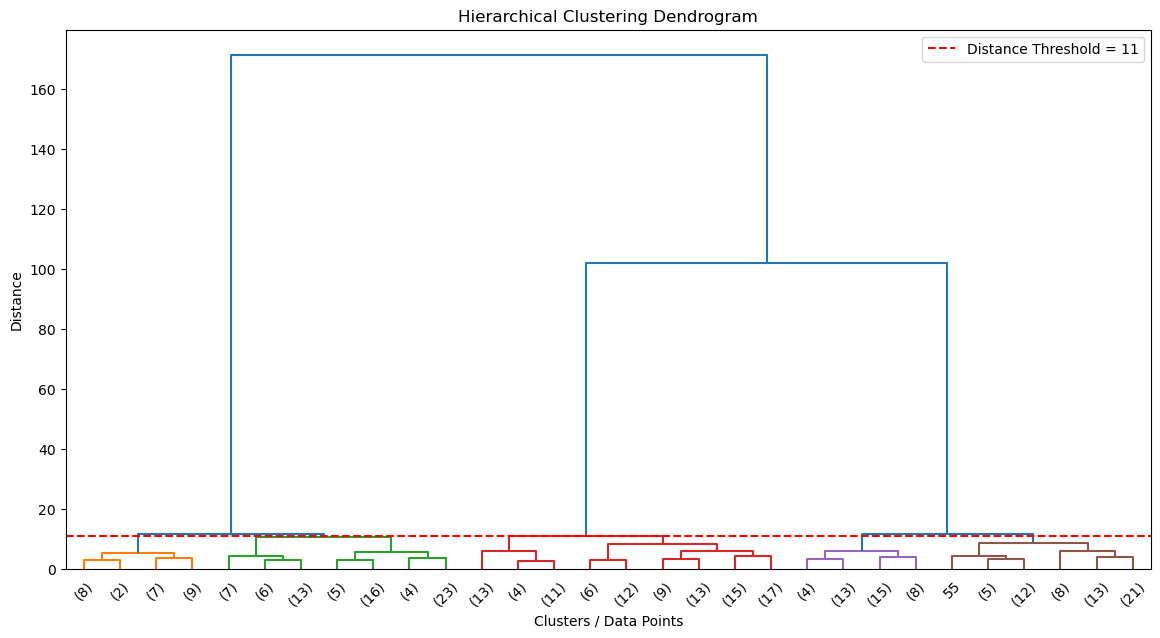

In [35]:
# # Dendrogram Graph
# from scipy.cluster.hierarchy import linkage, dendrogram
# import matplotlib.pyplot as plt

# Z = linkage(
#     X,
#     method="ward",
#     metric="euclidean"
# )

# plt.figure(figsize=(12, 6))

# dendrogram(
#     Z,
#     truncate_mode="lastp",
#     p=30
# )

# plt.title("Hierarchical Clustering Dendrogram")
# plt.xlabel("Clusters / Data Points")
# plt.ylabel("Distance")

# plt.show()


from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

Z = linkage(
    X,
    method="ward",
    metric="euclidean"
)

plt.figure(figsize=(14, 7))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=30,
    color_threshold=11
)

# Distance threshold ki line
plt.axhline(
    y=11,
    color="red",
    linestyle="--",
    label="Distance Threshold = 11"
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Clusters / Data Points")
plt.ylabel("Distance")
plt.legend()

plt.show()



300
Total clusters: 300


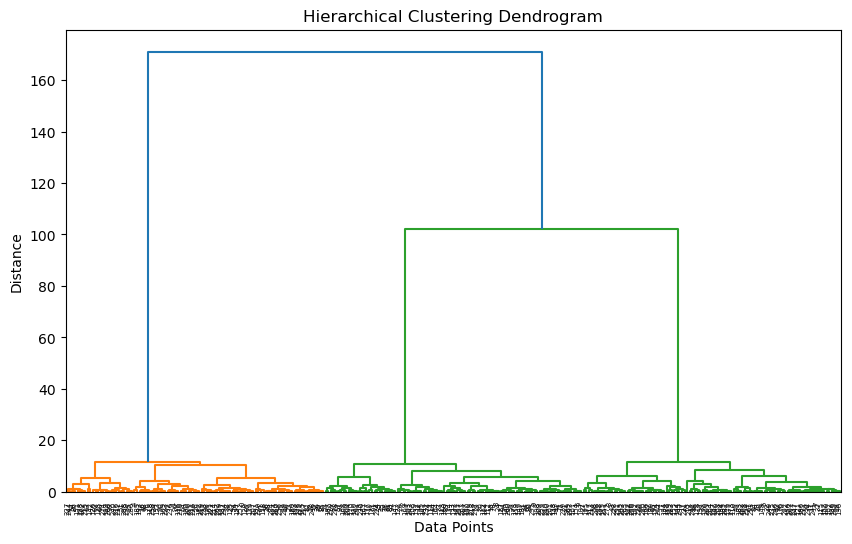

In [28]:
import warnings
warnings.filterwarnings("ignore")
# Divisive Clustering  ka kam keya with kmean Q ky is leya koi apna algorithm ni 

from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram


clusters = [X]
print(len(X))
while any(len(cluster) > 1 for cluster in clusters):

    new_clusters = []

    for cluster in clusters:

        # Agar cluster mein sirf 1 point hai,
        # to usko split nahi karna
        if len(cluster) == 1:
            new_clusters.append(cluster)
            continue

        # Cluster ko 2 parts mein split karo
        kmeans = KMeans(
            n_clusters=2,
            random_state=42,
            n_init=10
        )

        labels = kmeans.fit_predict(cluster)
        
        cluster_1 = cluster[labels == 0]
        cluster_2 = cluster[labels == 1]

        new_clusters.append(cluster_1)
        new_clusters.append(cluster_2)

    clusters = new_clusters

print("Total clusters:", len(clusters))

#graph
# Hierarchical clustering
Z = linkage(
    X,
    method="ward",
    metric="euclidean"
)

# Dendrogram
plt.figure(figsize=(10, 6))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()


# DBSCAN

DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
is main ya hota hain jaha point zeyada ho mean density zeyda ho tu ya khud he os ak cluster man leta hainn or jaha ak point ho mean kam ho tu ya os noise man leta hain 
Aapko pehle se clusters ki number K dene ki zaroorat nahi.
Ye irregular shapes ke clusters discover kar sakta hai.
Ye noise/outliers ko identify kar sakta hai.
Isliye ye K-Means se kaafi different hai.

hyperparameter
eps:
eps ka matlab hai neighborhood radius.
Yani: Kisi point ke around kitni distance tak hum doosre points ko uska neighbor consider karenge?

MinPts:
MinPts = min_samples
MinPts batata hai ke kisi point ke neighborhood mein minimum kitne points hone chahiye taake woh dense region ka part maana jaye.

types of points:

Core Point:
Agar kisi point ke eps neighborhood mein kam az kam MinPts points hain, to woh core point hai. matlab jitna humne radius(eps) deya hain os point ky eps main uthne point jitne humne boly hai yani MinPts ho tu ab wo Core point hain 
like: eps = 2 MinPts=4 ya jo p hain ya core point hoga 
       •
    •  P  •
       •

Border Point:
Border point khud sufficiently dense region mein nahi hota, lekin woh kisi core point ke neighborhood mein hota hai. matlab core point around bhot point hogay ji se dense ban jaye ga lakin ak point ya os zeyda point dor hain os dense area se lkain hum ne jo radius(eps) deya hain wo os main ate hain tu ab wo Border point hain 

      • • •
    • • P • •
      • • •     •(Border Point)

Noise Point:
Agar koi point: core point nahi hai, aur kisi core point ke neighborhood(radius) mein bhi nahi hai, to DBSCAN usay noise/outlier classify karta hai.

      • • •
    • • P • •
      • • •     •(Border Point)

                                  • (Noise Point)                                  


DSCAN ka fundamental idea bohot simple hai:
Dense areas ko clusters samjho aur sparse areas ko noise samjho.

Agar clusters kuch is tarah hon:

     ********
   **        **
  **          **
   **        **
     ********

DBSCAN aise non-spherical cluster ko achhi tarah handle kar sakta hai.


Density Connectivity:
DBSCAN sirf ye nahi dekhta ke points close hain.Ye density-connected regions identify karta hai.
Suppose:
A • • B • • C • • D
A directly B ke qareeb hai.
B C ke qareeb hai.
C D ke qareeb hai.
A aur D directly close nahi bhi hon, phir bhi agar density condition maintain ho rahi hai to DBSCAN unko same cluster mein connect kar sakta hai.
Isi wajah se DBSCAN complex shapes discover kar sakta hai.

effect:

Agar eps bohot chhota ho:
Neighborhoods chhote ho jayenge. bohot saare points noise ban sakte hain clusters toot sakte hain
Agar eps bohot bara ho:
Different clusters merge ho sakte hain.


Agar MinPts bohot low hai:
chhoti dense regions bhi cluster ban sakti hain
noise ko cluster samajhne ka chance increase hota hai
Agar MinPts bohot high hai:
genuine clusters bhi noise ban sakte hain
dense region ki requirement strict ho jati hai

agar do alag alag data set hain ak dense or ak spare tu 
to ek hi eps aur MinPts dono clusters ke liye ideal nahi ho sakte.

DBSCAM main noise ka cluter mean on lo lable -1 se keya jata hain 
label        
0 →   Cluster 0
1 →   Cluster 1
2 →   Cluster 2
3 →   Cluster 2
-1 →  Noise
noise = X[labels == -1]




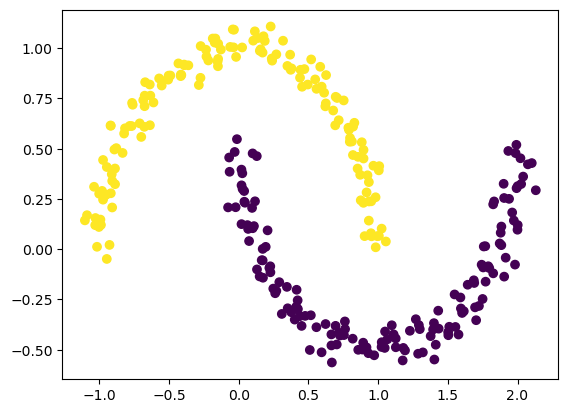

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

X, y = make_moons(
    n_samples=300,
    noise=0.05,
    random_state=42
)

model = DBSCAN(
    eps=0.3,
    min_samples=5
)

labels = model.fit_predict(X)

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    cmap="viridis"
)

plt.show()
